# 04 — Feature Engineering

## Telco Customer Churn Prediction

### Objective

Create, evaluate, and select meaningful features that can improve customer churn prediction.

This notebook covers:

- Feature creation
- Feature transformation
- Feature selection
- Correlation analysis
- Multicollinearity analysis
- Feature importance
- Feature engineering validation
- Prevention of data leakage

### Principle

Features must represent information that would realistically be available at the time a churn prediction is generated.

In [2]:
# importing libraries
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [4]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [5]:
X_train = pd.read_csv(
    PROCESSED_DATA_DIR / "X_train.csv"
)

X_val = pd.read_csv(
    PROCESSED_DATA_DIR / "X_validation.csv"
)

X_test = pd.read_csv(
    PROCESSED_DATA_DIR / "X_test.csv"
)

y_train = pd.read_csv(
    PROCESSED_DATA_DIR / "y_train.csv"
).squeeze()

y_val = pd.read_csv(
    PROCESSED_DATA_DIR / "y_validation.csv"
).squeeze()

y_test = pd.read_csv(
    PROCESSED_DATA_DIR / "y_test.csv"
).squeeze()

In [6]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (4930, 45)
X_val: (1056, 45)
X_test: (1057, 45)
y_train: (4930,)
y_val: (1056,)
y_test: (1057,)


In [7]:
display(X_train.head())
print(X_train.dtypes)

,numerical__seniorcitizen,numerical__tenure,numerical__monthlycharges,numerical__totalcharges,categorical__gender_Female,categorical__gender_Male,categorical__partner_No,categorical__partner_Yes,categorical__dependents_No,categorical__dependents_Yes,...,categorical__streamingmovies_Yes,categorical__contract_Month-to-month,categorical__contract_One year,categorical__contract_Two year,categorical__paperlessbilling_No,categorical__paperlessbilling_Yes,categorical__paymentmethod_Bank transfer (automatic),categorical__paymentmethod_Credit card (automatic),categorical__paymentmethod_Electronic check,categorical__paymentmethod_Mailed check
0,-0.438147,-1.114728,0.504286,-0.837871,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.282338,-1.195884,0.724189,-0.909151,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.438147,-1.195884,0.337292,-0.910985,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.438147,1.117066,0.515860,1.110142,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.438147,-0.830682,1.122660,-0.516301,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


numerical__seniorcitizen                                float64
numerical__tenure                                       float64
numerical__monthlycharges                               float64
numerical__totalcharges                                 float64
categorical__gender_Female                              float64
categorical__gender_Male                                float64
categorical__partner_No                                 float64
categorical__partner_Yes                                float64
categorical__dependents_No                              float64
categorical__dependents_Yes                             float64
categorical__phoneservice_No                            float64
categorical__phoneservice_Yes                           float64
categorical__multiplelines_No                           float64
categorical__multiplelines_No phone service             float64
categorical__multiplelines_Yes                          float64
categorical__internetservice_DSL        

In [8]:
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

In [9]:
# Identify original feature groups from the processed column names.
# The processed data are one-hot encoded, so each original categorical
# feature is represented by several columns (e.g. categorical__gender_Female).
customer_features = [
    col
    for col in X_train.columns
    if col.startswith("numerical__seniorcitizen")
    or col.startswith("categorical__gender_")
    or col.startswith("categorical__partner_")
    or col.startswith("categorical__dependents_")
]

service_features = [
    col
    for col in X_train.columns
    if col.startswith("categorical__phoneservice_")
    or col.startswith("categorical__multiplelines_")
    or col.startswith("categorical__internetservice_")
    or col.startswith("categorical__onlinesecurity_")
    or col.startswith("categorical__onlinebackup_")
    or col.startswith("categorical__deviceprotection_")
    or col.startswith("categorical__techsupport_")
    or col.startswith("categorical__streamingtv_")
    or col.startswith("categorical__streamingmovies_")
]

account_features = [
    col
    for col in X_train.columns
    if col.startswith("numerical__tenure")
    or col.startswith("categorical__contract_")
    or col.startswith("categorical__paperlessbilling_")
    or col.startswith("categorical__paymentmethod_")
]

financial_features = [
    col
    for col in X_train.columns
    if col.startswith("numerical__monthlycharges")
    or col.startswith("numerical__totalcharges")
]


In [10]:
# Check which features are available in the training set
available_features = set(X_train.columns)

for group_name, features in {
    "customer": customer_features,
    "service": service_features,
    "account": account_features,
    "financial": financial_features
}.items():

    print(f"\n{group_name.upper()}")

    for feature in features:
        print(
            feature,
            "✓" if feature in available_features else "✗"
        )


CUSTOMER
numerical__seniorcitizen ✓
categorical__gender_Female ✓
categorical__gender_Male ✓
categorical__partner_No ✓
categorical__partner_Yes ✓
categorical__dependents_No ✓
categorical__dependents_Yes ✓

SERVICE
categorical__phoneservice_No ✓
categorical__phoneservice_Yes ✓
categorical__multiplelines_No ✓
categorical__multiplelines_No phone service ✓
categorical__multiplelines_Yes ✓
categorical__internetservice_DSL ✓
categorical__internetservice_Fiber optic ✓
categorical__internetservice_No ✓
categorical__onlinesecurity_No ✓
categorical__onlinesecurity_No internet service ✓
categorical__onlinesecurity_Yes ✓
categorical__onlinebackup_No ✓
categorical__onlinebackup_No internet service ✓
categorical__onlinebackup_Yes ✓
categorical__deviceprotection_No ✓
categorical__deviceprotection_No internet service ✓
categorical__deviceprotection_Yes ✓
categorical__techsupport_No ✓
categorical__techsupport_No internet service ✓
categorical__techsupport_Yes ✓
categorical__streamingtv_No ✓
categorical

In [11]:

def create_total_services(df):
    """Create a new feature that counts the total number of
    add-on services a customer has subscribed to.

    The processed data are one-hot encoded, so the function sums the
    '..._Yes' indicator columns for the relevant service features.
    """  # noqa: D205
    df = df.copy()

    service_yes_columns = [
        col
        for col in df.columns
        if any(
            col.startswith(f"categorical__{service}_Yes")
            for service in [
                "phoneservice",
                "multiplelines",
                "onlinesecurity",
                "onlinebackup",
                "deviceprotection",
                "techsupport",
                "streamingtv",
                "streamingmovies",
            ]
        )
    ]

    df["total_services"] = df[service_yes_columns].sum(axis=1)

    return df


In [12]:
# Create the total_services feature for the training, validation, and test sets
X_train = create_total_services(X_train)
X_val = create_total_services(X_val)
X_test = create_total_services(X_test)

print("Added 'total_services' to all sets.")
print("\nTraining distribution:")
print(X_train["total_services"].value_counts().sort_index())


Added 'total_services' to all sets.

Training distribution:
total_services
0.0      53
1.0    1197
2.0     803
3.0     673
4.0     652
5.0     635
6.0     478
7.0     276
8.0     163
Name: count, dtype: int64


In [13]:
# Validate the new feature and inspect its relationship with churn
for split_name, df in [
    ("train", X_train),
    ("val", X_val),
    ("test", X_test),
]:
    assert df["total_services"].between(0, 8).all(), (
        f"{split_name}: total_services out of expected range"
    )
    assert df["total_services"].notna().all(), (
        f"{split_name}: total_services contains missing values"
    )

print("Validation passed: total_services is in range and has no missing values.")

# Relationship between total_services and churn in the training set
churn_by_services = (
    pd.concat([X_train["total_services"], y_train], axis=1) # type: ignore
    .groupby("total_services")["churn"]
    .agg(["count", "mean"])
    .round(3)
)

churn_by_services


Validation passed: total_services is in range and has no missing values.


,count,mean
total_services,,
0.0,53,0.434
1.0,1197,0.205
2.0,803,0.320
3.0,673,0.373
4.0,652,0.325
5.0,635,0.258
6.0,478,0.236
7.0,276,0.127
8.0,163,0.049


In [14]:

def create_security_service_feature(df):
    """Create a binary feature that indicates whether a customer has security service.

    The processed data are one-hot encoded, so the function checks whether
    any of the relevant `categorical__<service>_Yes` columns equals 1.
    """
    df = df.copy()

    security_yes_columns = [
        col
        for col in df.columns
        if col.startswith(
            (
                "categorical__onlinesecurity_Yes",
                "categorical__onlinebackup_Yes",
                "categorical__deviceprotection_Yes",
                "categorical__techsupport_Yes",
            )
        )
    ]

    df["has_security_service"] = (
        df[security_yes_columns]
        .eq(1)
        .any(axis=1)
        .astype(int)
    )

    return df


In [15]:
# Create a new feature that indicates whether a customer has any security services.
X_train = create_security_service_feature(X_train)
X_val = create_security_service_feature(X_val)
X_test = create_security_service_feature(X_test)

In [16]:
def create_streaming_feature(df):
    """Create a binary feature that indicates whether a customer has any streaming service.

    The processed data are one-hot encoded, so the function checks whether
    any of the relevant `categorical__<service>_Yes` columns equals 1.
    """
    df = df.copy()

    streaming_columns = [
        col
        for col in df.columns
        if col.startswith(
            (
                "categorical__streamingtv_Yes",
                "categorical__streamingmovies_Yes",
            )
        )
    ]

    df["has_streaming_service"] = (
        df[streaming_columns]
        .eq(1)
        .any(axis=1)
        .astype(int)
    )

    return df

In [17]:
X_train = create_streaming_feature(X_train)
X_val = create_streaming_feature(X_val)
X_test = create_streaming_feature(X_test)

In [18]:
def create_contract_features(df):
    """Create binary contract features from one-hot encoded columns.

    The processed data are one-hot encoded, so the function uses the
    relevant `categorical__contract_...` indicator columns.
    """
    df = df.copy()

    # Flag for month-to-month contracts
    df["is_month_to_month"] = (
        df["categorical__contract_Month-to-month"]
        .eq(1)
        .astype(int)
    )

    # Flag for long-term contracts (one or two years)
    df["is_long_term_contract"] = (
        df[[
            "categorical__contract_One year",
            "categorical__contract_Two year",
        ]]
        .eq(1)
        .any(axis=1)
        .astype(int)
    )

    return df

In [19]:
X_train = create_contract_features(X_train)
X_val = create_contract_features(X_val)
X_test = create_contract_features(X_test)

In [20]:
def create_payment_method_features(df):
    """Create binary payment method features from one-hot encoded columns.

    The processed data are one-hot encoded, so the function uses the
    relevant `categorical__paymentmethod_...` indicator columns.
    """
    df = df.copy()

    # Flag for electronic check payment method
    df["is_electronic_check"] = (
        df["categorical__paymentmethod_Electronic check"]
        .eq(1)
        .astype(int)
    )

    # Flag for non-electronic check payment methods
    df["is_non_electronic_check"] = (
        df[[
            "categorical__paymentmethod_Mailed check",
            "categorical__paymentmethod_Bank transfer (automatic)",
            "categorical__paymentmethod_Credit card (automatic)",
        ]]
        .eq(1)
        .any(axis=1)
        .astype(int)
    )

    return df

In [21]:
X_train = create_contract_features(X_train)
X_val = create_contract_features(X_val)
X_test = create_contract_features(X_test)

In [22]:
def create_tenure_group(df):
    """Create a categorical feature that groups customers based on their tenure.

    The processed data are one-hot encoded, so the function creates a new
    categorical column based on the `numerical__tenure` column.
    """
    df = df.copy()

    # Define tenure groups
    bins = [0, 12, 24, 48, 60, np.inf]
    labels = [
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-60 months",
        "61+ months"
    ]

    # Create the tenure_group feature
    df["tenure_group"] = pd.cut(
        df["numerical__tenure"],
        bins=bins,
        labels=labels,
        right=False
    )

    return df

In [23]:
X_train = create_contract_features(X_train)
X_val = create_contract_features(X_val)
X_test = create_contract_features(X_test)

In [24]:
def create_payment_method_features(df):
    """Create binary payment method features from one-hot encoded columns.

    The processed data are one-hot encoded, so the function uses the
    relevant `categorical__paymentmethod_...` indicator columns.
    """
    df = df.copy()

    # Flag for electronic check payment method
    df["is_electronic_check"] = (
        df["categorical__paymentmethod_Electronic check"]
        .eq(1)
        .astype(int)
    )

    # Flag for non-electronic check payment methods
    df["is_non_electronic_check"] = (
        df[[
            "categorical__paymentmethod_Mailed check",
            "categorical__paymentmethod_Bank transfer (automatic)",
            "categorical__paymentmethod_Credit card (automatic)",
        ]]
        .eq(1)
        .any(axis=1)
        .astype(int)
    )

    return df

In [25]:
X_train = create_contract_features(X_train)
X_val = create_contract_features(X_val)
X_val = create_contract_features(X_val)

In [26]:
def create_charge_ratio_feature(df):
    """Create a new feature that calculates the ratio of total charges to tenure.

    The processed data are one-hot encoded, so the function uses the
    `numerical__totalcharges` and `numerical__tenure` columns.
    """
    df = df.copy()

    # Calculate the charge ratio
    df["charge_ratio"] = df["numerical__totalcharges"] / df["numerical__tenure"].replace(0, np.nan)

    return df

In [27]:
X_train = create_contract_features(X_train)
X_val = create_contract_features(X_val)
X_val = create_contract_features(X_val)

In [28]:
def engineer_features(df):
    """Engineer new features from the preprocessed Telco customer churn data.

    Creates aggregate service indicators, contract flags, payment method flags,
    and tenure-based grouping from the one-hot encoded columns.
    """
    df = df.copy()

    # Total services: sum the one-hot encoded `_Yes` indicator columns
    service_yes_columns = [
        col
        for col in df.columns
        if any(
            col.startswith(f"categorical__{service}_Yes")
            for service in [
                "phoneservice",
                "multiplelines",
                "onlinesecurity",
                "onlinebackup",
                "deviceprotection",
                "techsupport",
                "streamingtv",
                "streamingmovies",
            ]
        )
    ]

    df["total_services"] = df[service_yes_columns].sum(axis=1)

    # Security services: any relevant security `_Yes` column is active
    security_yes_columns = [
        col
        for col in df.columns
        if col.startswith(
            (
                "categorical__onlinesecurity_Yes",
                "categorical__onlinebackup_Yes",
                "categorical__deviceprotection_Yes",
                "categorical__techsupport_Yes",
            )
        )
    ]

    df["has_security_service"] = (
        df[security_yes_columns]
        .eq(1)
        .any(axis=1)
        .astype(int)
    )

    # Streaming services: any relevant streaming `_Yes` column is active
    streaming_columns = [
        col
        for col in df.columns
        if col.startswith(
            (
                "categorical__streamingtv_Yes",
                "categorical__streamingmovies_Yes",
            )
        )
    ]

    df["has_streaming_service"] = (
        df[streaming_columns]
        .eq(1)
        .any(axis=1)
        .astype(int)
    )

    # Contract features: use one-hot encoded contract columns
    df["is_month_to_month"] = (
        df["categorical__contract_Month-to-month"]
        .eq(1)
        .astype(int)
    )

    df["is_long_term_contract"] = (
        df[[
            "categorical__contract_One year",
            "categorical__contract_Two year",
        ]]
        .eq(1)
        .any(axis=1)
        .astype(int)
    )

    # Payment feature: use one-hot encoded payment method column
    df["is_electronic_payment"] = (
        df["categorical__paymentmethod_Electronic check"]
        .eq(1)
        .astype(int)
    )

    # Tenure group: use the scaled numerical tenure column
    bins = [-1, 6, 12, 24, 48, np.inf]

    labels = [
        "0-6_months",
        "7-12_months",
        "13-24_months",
        "25-48_months",
        "49+_months"
    ]

    df["tenure_group"] = pd.cut(
        df["numerical__tenure"],
        bins=bins,
        labels=labels
    )

    return df

In [29]:
X_train_fe = engineer_features(X_train)
X_val_fe = engineer_features(X_val)
X_test_fe = engineer_features(X_test)

In [30]:
print("Before:", X_train.shape)
print("After:", X_train_fe.shape)

Before: (4930, 50)
After: (4930, 52)


In [31]:
new_features = [
    "total_services",
    "has_security_service",
    "has_streaming_service",
    "is_month_to_month",
    "is_long_term_contract",
    "is_electronic_payment",
    "tenure_group"
]

In [32]:
X_train_fe[new_features].head()

,total_services,has_security_service,has_streaming_service,is_month_to_month,is_long_term_contract,is_electronic_payment,tenure_group
0,2.0,0,1,1,0,1,NaN
1,3.0,1,1,1,0,1,NaN
2,2.0,0,0,1,0,0,NaN
3,6.0,1,1,0,1,0,0-6_months
4,5.0,1,1,1,0,0,0-6_months


In [33]:
X_train_fe[new_features].isna().sum()

total_services              0
has_security_service        0
has_streaming_service       0
is_month_to_month           0
is_long_term_contract       0
is_electronic_payment       0
tenure_group             1120
dtype: int64

In [34]:
for feature in new_features:
    print(f"\n{feature}")

print(X_train_fe[feature].value_counts(dropna=False))

for feature in new_features:
    print(f"\n{feature}")
    print(X_train_fe[feature].value_counts(dropna=False))


total_services

has_security_service

has_streaming_service

is_month_to_month

is_long_term_contract

is_electronic_payment

tenure_group
tenure_group
0-6_months      3810
NaN             1120
7-12_months        0
13-24_months       0
25-48_months       0
49+_months         0
Name: count, dtype: int64

total_services
total_services
1.0    1197
2.0     803
3.0     673
4.0     652
5.0     635
6.0     478
7.0     276
8.0     163
0.0      53
Name: count, dtype: int64

has_security_service
has_security_service
1    2997
0    1933
Name: count, dtype: int64

has_streaming_service
has_streaming_service
1    2468
0    2462
Name: count, dtype: int64

is_month_to_month
is_month_to_month
1    2704
0    2226
Name: count, dtype: int64

is_long_term_contract
is_long_term_contract
0    2704
1    2226
Name: count, dtype: int64

is_electronic_payment
is_electronic_payment
0    3276
1    1654
Name: count, dtype: int64

tenure_group
tenure_group
0-6_months      3810
NaN             1120
7-12_months     

In [35]:
train_analysis = X_train_fe.copy()
train_analysis["churn"] = y_train.values

In [36]:
binary_features = [
    "has_security_service",
    "has_streaming_service",
    "is_month_to_month",
    "is_long_term_contract",
    "is_electronic_payment"
]

In [37]:
for feature in binary_features:
    churn_rate = (
        train_analysis
        .groupby(feature)["churn"]
        .mean()
        .mul(100)
        .round(2)
    )
    print(f"Churn rate for {feature}:\n{churn_rate}\n")

Churn rate for has_security_service:
has_security_service
0    29.38
1    24.69
Name: churn, dtype: float64

Churn rate for has_streaming_service:
has_streaming_service
0    22.58
1    30.47
Name: churn, dtype: float64

Churn rate for is_month_to_month:
is_month_to_month
0     6.69
1    42.86
Name: churn, dtype: float64

Churn rate for is_long_term_contract:
is_long_term_contract
0    42.86
1     6.69
Name: churn, dtype: float64

Churn rate for is_electronic_payment:
is_electronic_payment
0    16.88
1    45.65
Name: churn, dtype: float64



In [38]:
# Total services vs churn
churn_rate_by_service = (
    train_analysis
    .groupby("total_services")["churn"]
    .mean()
    .mul(100)
    .round(2)
)

churn_rate_by_service

total_services
0.0    43.40
1.0    20.47
2.0    32.00
3.0    37.30
4.0    32.52
5.0    25.83
6.0    23.64
7.0    12.68
8.0     4.91
Name: churn, dtype: float64

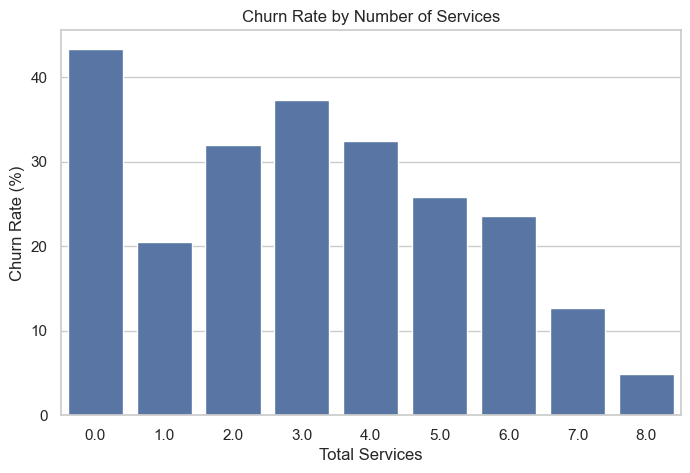

In [39]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=churn_rate_by_service.index,
    y=churn_rate_by_service.values)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Total Services")
plt.ylabel("Churn Rate (%)")
plt.show()

In [40]:
# Tenure group vs churn
churn_rate_by_tenure_group = (
    train_analysis
    .groupby(
        "tenure_group",
        observed=True
    )["churn"]
    .mean()
    .mul(100)
    .round(2)
)

churn_rate_by_tenure_group

tenure_group
0-6_months    19.19
Name: churn, dtype: float64

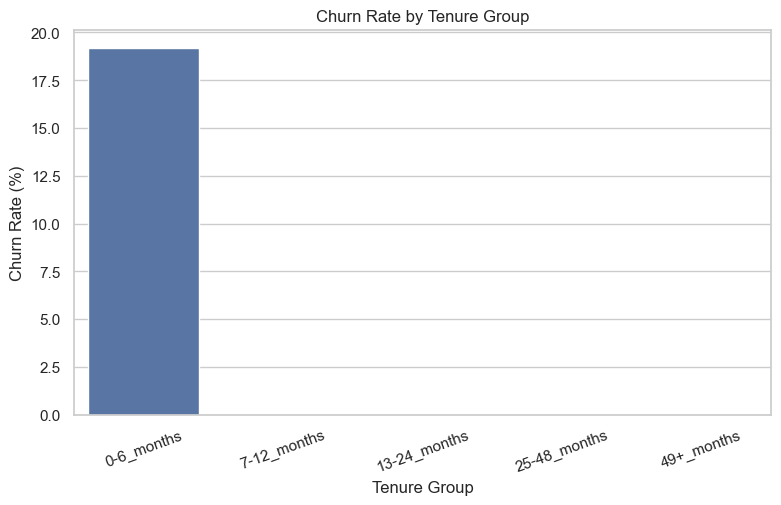

In [41]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=churn_rate_by_tenure_group.index,
    y=churn_rate_by_tenure_group.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [42]:
# Correlation analysis

numeric_features = (
    X_train_fe.select_dtypes(include=[np.number])
    .columns.
    tolist()
)

numeric_features

['numerical__seniorcitizen',
 'numerical__tenure',
 'numerical__monthlycharges',
 'numerical__totalcharges',
 'categorical__gender_Female',
 'categorical__gender_Male',
 'categorical__partner_No',
 'categorical__partner_Yes',
 'categorical__dependents_No',
 'categorical__dependents_Yes',
 'categorical__phoneservice_No',
 'categorical__phoneservice_Yes',
 'categorical__multiplelines_No',
 'categorical__multiplelines_No phone service',
 'categorical__multiplelines_Yes',
 'categorical__internetservice_DSL',
 'categorical__internetservice_Fiber optic',
 'categorical__internetservice_No',
 'categorical__onlinesecurity_No',
 'categorical__onlinesecurity_No internet service',
 'categorical__onlinesecurity_Yes',
 'categorical__onlinebackup_No',
 'categorical__onlinebackup_No internet service',
 'categorical__onlinebackup_Yes',
 'categorical__deviceprotection_No',
 'categorical__deviceprotection_No internet service',
 'categorical__deviceprotection_Yes',
 'categorical__techsupport_No',
 'catego

In [43]:
correlation_matrix = (
    X_train_fe[numeric_features]
    .corr()
)

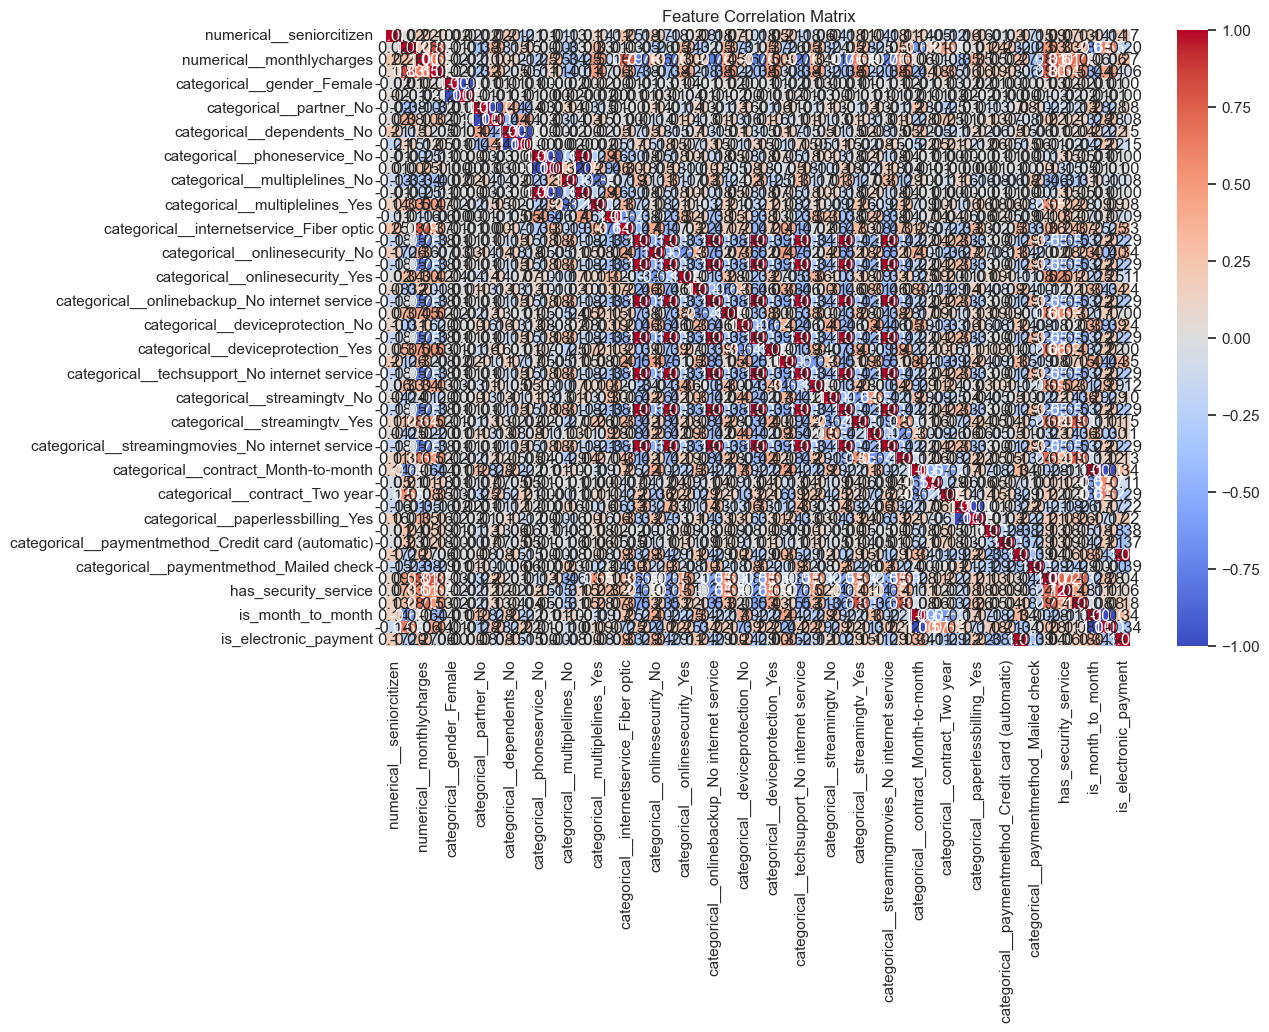

In [44]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [45]:
# Correlation with target
correlation_with_target = (
    train_analysis[numeric_features + ["churn"]]
    .corr()["churn"]
    .drop("churn")
    .sort_values(
        key=abs,
        ascending=False)
)
correlation_with_target

is_long_term_contract                                  -0.407682
is_month_to_month                                       0.407682
categorical__contract_Month-to-month                    0.407682
categorical__onlinesecurity_No                          0.347257
numerical__tenure                                      -0.343520
categorical__techsupport_No                             0.341281
categorical__internetservice_Fiber optic                0.308472
is_electronic_payment                                   0.307645
categorical__paymentmethod_Electronic check             0.307645
categorical__contract_Two year                         -0.300721
categorical__onlinebackup_No                            0.273142
categorical__deviceprotection_No                        0.251416
categorical__streamingmovies_No internet service       -0.233487
categorical__techsupport_No internet service           -0.233487
categorical__onlinebackup_No internet service          -0.233487
categorical__onlinesecuri

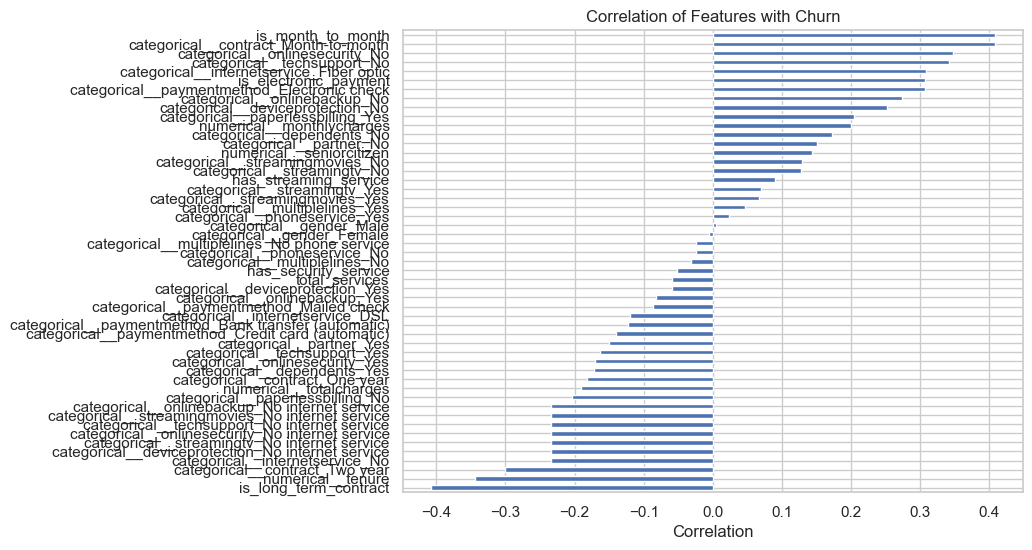

In [46]:
plt.figure(figsize=(8, 6))

correlation_with_target.sort_values().plot(
    kind="barh"
)

plt.title("Correlation of Features with Churn")
plt.xlabel("Correlation")
plt.show()

In [47]:
# Calculate VIF

vif_features  = X_train_fe.select_dtypes(include=[np.number]).copy()

In [48]:
vif_features = vif_features.fillna(vif_features.median())

In [49]:
vif_data = pd.DataFrame()

vif_data["feature"] = vif_features.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        vif_features.values,
        i
    )
    for i in range(vif_features.shape[1])
]

vif_data.sort_values(
    "VIF",
    ascending=False
)

c:\Users\USER\anaconda3\envs\telco.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
25,categorical__deviceprotection_No internet service,inf
36,categorical__contract_Month-to-month,inf
27,categorical__techsupport_No,inf
28,categorical__techsupport_No internet service,inf
29,categorical__techsupport_Yes,inf
30,categorical__streamingtv_No,inf
31,categorical__streamingtv_No internet service,inf
32,categorical__streamingtv_Yes,inf
33,categorical__streamingmovies_No,inf
34,categorical__streamingmovies_No internet service,inf


In [50]:
# Identify highly correlated features (correlation >= 0.80)

corr_matrix = X_train_fe[
    numeric_features
].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

high_correlation_pairs = (
    high_correlation_pairs[
        high_correlation_pairs["correlation"] >= 0.80
    ]
    .sort_values(
        "correlation",
        ascending=False
    )
)

high_correlation_pairs

,feature_1,feature_2,correlation
1272,is_month_to_month,is_long_term_contract,1.000000
194,categorical__gender_Female,categorical__gender_Male,1.000000
372,categorical__dependents_No,categorical__dependents_Yes,1.000000
1209,categorical__paperlessbilling_No,categorical__paperlessbilling_Yes,1.000000
1182,categorical__contract_Month-to-month,is_long_term_contract,1.000000
958,categorical__deviceprotection_No internet service,categorical__streamingmovies_No internet service,1.000000
874,categorical__onlinebackup_No internet service,categorical__techsupport_No internet service,1.000000
877,categorical__onlinebackup_No internet service,categorical__streamingtv_No internet service,1.000000
880,categorical__onlinebackup_No internet service,categorical__streamingmovies_No internet service,1.000000
952,categorical__deviceprotection_No internet service,categorical__techsupport_No internet service,1.000000


In [51]:
numeric_X_train = X_train_fe.select_dtypes(
    include=np.number
).copy()

numeric_X_train = numeric_X_train.fillna(
    numeric_X_train.median()
)

In [52]:
mi_scores = mutual_info_classif(
    numeric_X_train,
    y_train,
    random_state=42
)

In [53]:
mi_results = pd.DataFrame({
    "feature": numeric_X_train.columns,
    "mutual_information": mi_scores
}).sort_values(
    "mutual_information",
    ascending=False
)

mi_results

,feature,mutual_information
49,is_long_term_contract,0.096471
36,categorical__contract_Month-to-month,0.094361
48,is_month_to_month,0.092186
1,numerical__tenure,0.074370
38,categorical__contract_Two year,0.068418
18,categorical__onlinesecurity_No,0.060086
27,categorical__techsupport_No,0.050915
16,categorical__internetservice_Fiber optic,0.049658
50,is_electronic_payment,0.048717
2,numerical__monthlycharges,0.048255


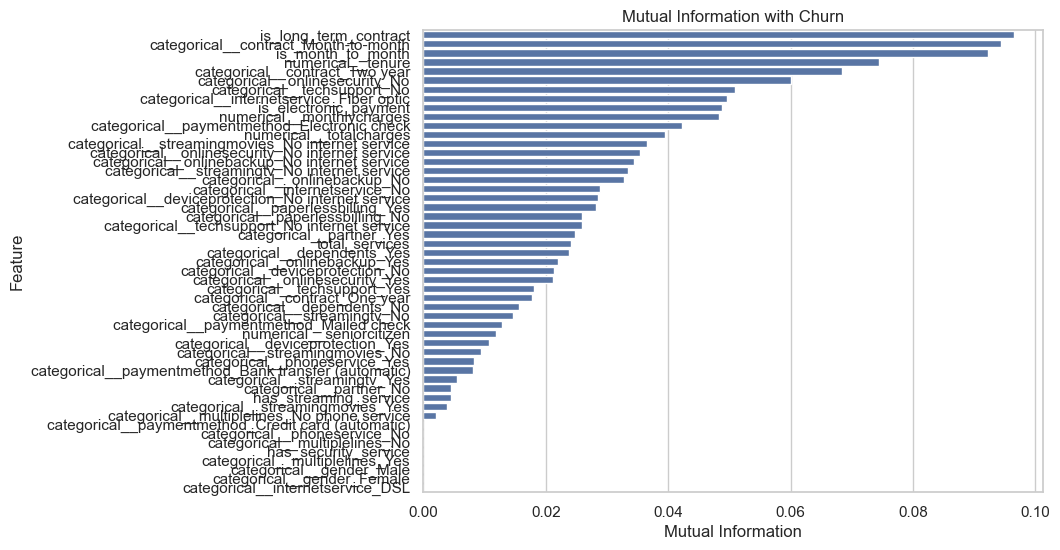

In [54]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=mi_results,
    x="mutual_information",
    y="feature"
)

plt.title("Mutual Information with Churn")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.show()

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
X_train_numeric = pd.get_dummies(
    X_train_fe,
    drop_first=True
)
X_train_numeric = X_train_numeric.fillna(X_train_numeric.median(numeric_only=True))

In [57]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(
    X_train_numeric,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [58]:
rf_importance = pd.DataFrame({
    "feature": X_train_numeric.columns, 
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=True
)

In [59]:
rf_importance.head(20)

,feature,importance
54,tenure_group_49+_months,0.000000
52,tenure_group_13-24_months,0.000000
51,tenure_group_7-12_months,0.000000
53,tenure_group_25-48_months,0.000000
28,categorical__techsupport_No internet service,0.002056
10,categorical__phoneservice_No,0.002738
11,categorical__phoneservice_Yes,0.002743
13,categorical__multiplelines_No phone service,0.002786
25,categorical__deviceprotection_No internet service,0.003216
31,categorical__streamingtv_No internet service,0.003250


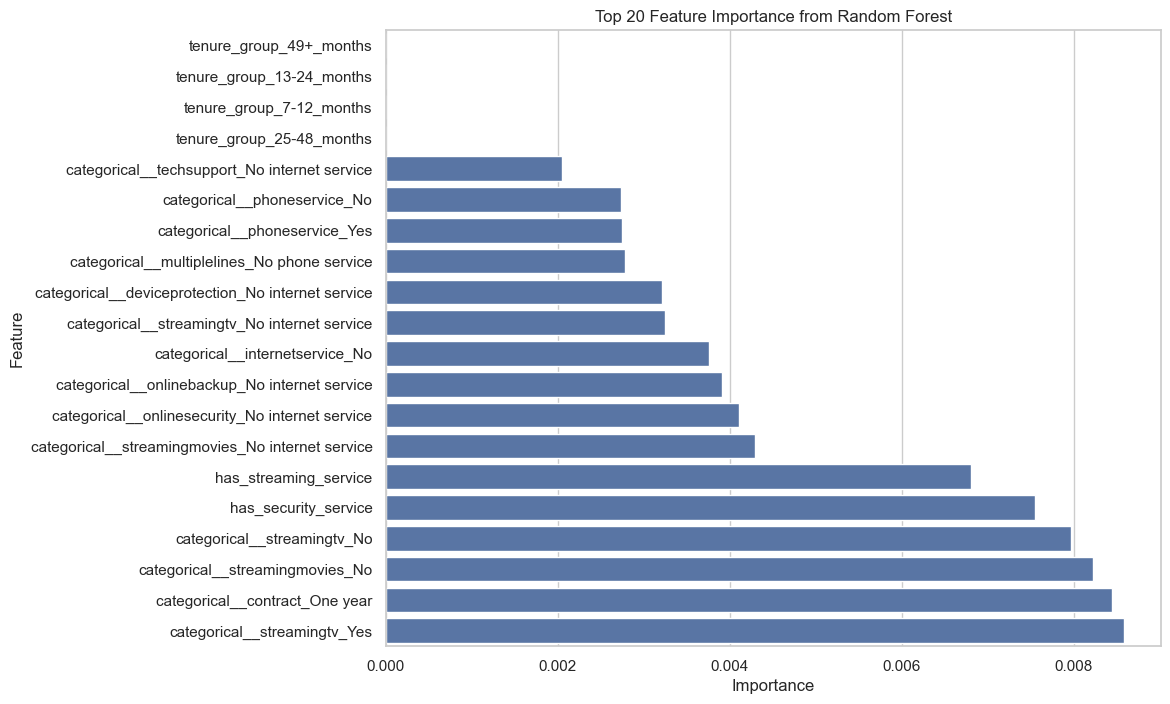

In [60]:
top_features = rf_importance.head(20)
plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [61]:
# Prepare validation data the same way as training data for permutation importance
X_val_numeric = pd.get_dummies(
    X_val_fe,
    drop_first=True
)

# Align columns with the training set and fill missing values
X_val_numeric = X_val_numeric.reindex(
    columns=X_train_numeric.columns,
    fill_value=0
)

X_val_numeric = X_val_numeric.fillna(
    X_val_numeric.median(numeric_only=True)
)

print("X_val_numeric shape:", X_val_numeric.shape)


X_val_numeric shape: (1056, 55)


In [62]:
perm_importance = permutation_importance(
    rf,
    X_val_numeric,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)


In [63]:
importance_df = pd.DataFrame({
    "feature": X_val_numeric.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

In [64]:
feature_decisions = pd.DataFrame({
    "feature": [
        "tenure",
        "monthlycharges",
        "totalcharges",
        "total_services",
        "has_security_service",
        "has_streaming_service",
        "is_month_to_month",
        "is_long_term_contract",
        "is_electronic_payment",
        "tenure_group"
    ],
    "decision": [
        "Keep",
        "Keep",
        "Keep",
        "Evaluate",
        "Evaluate",
        "Evaluate",
        "Keep",
        "Evaluate",
        "Evaluate",
        "Evaluate"
    ],
    "reason": [
        "Core customer tenure signal",
        "Direct billing signal",
        "Historical customer spending",
        "Aggregated service usage",
        "Aggregated security-service indicator",
        "Aggregated streaming-service indicator",
        "Strong contract representation",
        "Contract duration representation",
        "Payment behavior representation",
        "Nonlinear tenure representation"
    ]
})

feature_decisions

,feature,decision,reason
0,tenure,Keep,Core customer tenure signal
1,monthlycharges,Keep,Direct billing signal
2,totalcharges,Keep,Historical customer spending
3,total_services,Evaluate,Aggregated service usage
4,has_security_service,Evaluate,Aggregated security-service indicator
5,has_streaming_service,Evaluate,Aggregated streaming-service indicator
6,is_month_to_month,Keep,Strong contract representation
7,is_long_term_contract,Evaluate,Contract duration representation
8,is_electronic_payment,Evaluate,Payment behavior representation
9,tenure_group,Evaluate,Nonlinear tenure representation


In [65]:
baseline_features = [
    column
    for column in X_train.columns
]

In [66]:
engineered_features = [
    column
    for column in X_train_fe.columns
]

In [67]:
print(
    f"Baseline featueres:",
    {len(baseline_features)})

print(
    f"Engineered features",
    {len(engineered_features)}
)

Baseline featueres: {50}
Engineered features {52}


In [68]:
assert list(X_train_fe.columns) == list(X_val_fe.columns)


assert list(X_train_fe.columns) == list(X_test_fe.columns)

In [69]:
assert X_train_fe.shape[1] == X_val_fe.shape[1]

assert X_train_fe.shape[1] == X_test_fe.shape[1]

In [70]:
# Checking leakage

forbidden_features = [
    "churn",
    "churn_probability",
    "churn_prediction"
]

leaked_features = [
    feature
    for feature in X_train_fe.columns
    if feature.lower() in forbidden_features
]

print(f"Potential leakage: {leaked_features}")

Potential leakage: []


In [71]:

# Save feature-engineered dataset
FEATURE_ENGINEERED_DIR = PROCESSED_DATA_DIR / "feature_engineered"
FEATURE_ENGINEERED_DIR.mkdir(parents=True, exist_ok=True)

X_train_fe.to_csv(
    FEATURE_ENGINEERED_DIR / "X_train_feature_engineered.csv",
    index=False
)

X_val_fe.to_csv(
    FEATURE_ENGINEERED_DIR / "X_validation_feature_engineered.csv",
    index=False
)

X_test_fe.to_csv(
    FEATURE_ENGINEERED_DIR / "X_test_feature_engineered.csv",
    index=False
)


In [72]:
# 40
import json

In [73]:
feature_config = {
    "engineered_features": [
        "total_services",
        "has_security_service",
        "has_streaming_service",
        "is_month_to_month",
        "is_long_term_contract",
        "is_electronic_payment",
        "tenure_group"
    ]
}

In [74]:
FEATURE_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "feature_config.json"
)

FEATURE_CONFIG_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

with open(FEATURE_CONFIG_PATH, "w") as file:
    json.dump(
        feature_config,
        file,
        indent=4
    )

In [75]:
# 41

summary = pd.DataFrame({
    "Metric": [
        "Original feature count",
        "Feature-engineered count",
        "New features created",
        "Training rows",
        "Validation rows",
        "Test rows"
    ],
    "Value": [
        X_train.shape[1],
        X_train_fe.shape[1],
        X_train_fe.shape[1] - X_train.shape[1],
        X_train_fe.shape[0],
        X_val_fe.shape[0],
        X_test_fe.shape[0]
    ]
})

summary

,Metric,Value
0,Original feature count,50
1,Feature-engineered count,52
2,New features created,2
3,Training rows,4930
4,Validation rows,1056
5,Test rows,1057


## Feature Engineering Conclusions

### Features Created

The following business-oriented features were evaluated:

- `total_services`
- `has_security_service`
- `has_streaming_service`
- `is_month_to_month`
- `is_long_term_contract`
- `is_electronic_payment`
- `tenure_group`

### Feature Analysis

Features were assessed using:

- Domain knowledge
- Distribution analysis
- Correlation analysis
- Multicollinearity diagnostics
- Mutual information
- Model-based feature importance

### Important Findings

Feature engineering does not guarantee improved model performance.

The final feature set will therefore be determined experimentally by comparing models trained using:

1. Original features.
2. Original + engineered features.
3. Selected feature subset.

The validation dataset will be used to compare these alternatives while keeping the test set untouched.

### Leakage Prevention

Feature engineering operations that learn from data will be fitted using training data only.

No target-derived feature is used as an input.

### Next Step

The resulting feature sets will be passed to model training and evaluated using consistent validation procedures.